C:\Users\bhana\AppData\Local\Temp\ipykernel_34472\2599589932.py:13: DtypeWarning: Columns (9: act, 10: emotion) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/message_features.csv")


DEAD : ['n_emoji', 'has_emoji', 'emoji_per_word', 'n_emoticon', 'has_newline', 'has_list']
ALIVE: ['n_words', 'n_chars', 'log_words', 'n_sentences', 'avg_sent_len', 'punct_density', 'n_questions', 'n_exclam', 'has_ellipsis', 'caps_ratio', 'starts_lower']
Highly correlated pairs:
n_words     log_words       1.000
            n_chars         0.966
n_chars     log_words       0.966
caps_ratio  starts_lower   -0.931
dtype: float64
SELECTED: ['starts_lower', 'n_chars', 'n_exclam', 'n_sentences', 'punct_density', 'avg_sent_len', 'n_questions', 'has_ellipsis']


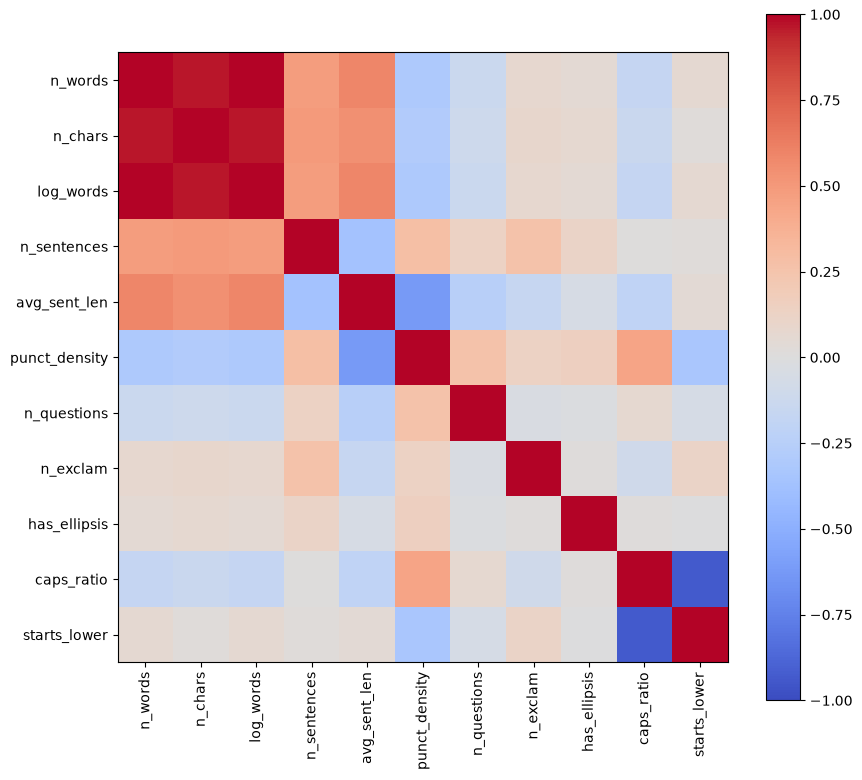

In [1]:

import sys, json; sys.path.append("..")
from pathlib import Path
import numpy as np, pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from src.features.extractor import FEATURES
from src.profiling.stats import icc1

MIN_NONZERO = 0.01        # feature must be non-zero in >=1% of messages (in some dataset)
CORR_THRESHOLD = 0.85     # |Spearman| above this = redundant
OUT = Path("../docs/findings"); OUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv("../data/processed/message_features.csv")
df["spk_key"] = df["conversation_id"].astype(str) + "_" + df["speaker_id"].astype(str)

nonzero = pd.DataFrame({ds: (g[FEATURES] != 0).mean() for ds, g in df.groupby("dataset")})
std = pd.DataFrame({ds: g[FEATURES].std() for ds, g in df.groupby("dataset")})
alive = [f for f in FEATURES
         if (nonzero.loc[f] >= MIN_NONZERO).any() and (std.loc[f] > 1e-9).any()]
dead = [f for f in FEATURES if f not in alive]
print("DEAD :", dead)
print("ALIVE:", alive)
nonzero.round(3).to_csv(OUT / "nonzero_rate.csv")
nonzero.round(3)

corr = df[alive].corr(method="spearman")
corr.round(3).to_csv(OUT / "feature_corr.csv")
pairs = (corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack()
             .loc[lambda s: s.abs() >= CORR_THRESHOLD].sort_values(key=abs, ascending=False))
print("Highly correlated pairs:"); print(pairs.round(3))

try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(alive)), alive, rotation=90); ax.set_yticks(range(len(alive)), alive)
    fig.colorbar(im); fig.tight_layout(); fig.savefig(OUT / "feature_corr.png", dpi=150)
except ImportError:
    pass


dist = 1 - corr.abs().fillna(0).values
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method="average")
labels = fcluster(Z, t=1 - CORR_THRESHOLD, criterion="distance")

icc = pd.DataFrame({ds: {f: icc1(g[f], g["spk_key"]) for f in alive}
                    for ds, g in df.groupby("dataset")})
icc["mean_icc"] = icc.mean(axis=1)

groups = pd.DataFrame({"feature": alive, "group": labels}).join(icc["mean_icc"], on="feature")
selected = (groups.sort_values("mean_icc", ascending=False, na_position="last")
                  .groupby("group").head(1)["feature"].tolist())
groups["kept"] = groups["feature"].isin(selected)
groups.sort_values(["group", "mean_icc"], ascending=[True, False]).round(3).to_csv(
    OUT / "feature_groups.csv", index=False)
icc.round(3).to_csv(OUT / "icc_by_dataset.csv")
print("SELECTED:", selected)
groups.sort_values(["group", "mean_icc"], ascending=[True, False]).round(3)
X = df[selected]
Xs = ((X - X.mean()) / X.std()).fillna(0).values
s = np.linalg.svd(Xs, compute_uv=False)
evr = s ** 2 / (s ** 2).sum()
pca = pd.DataFrame({"component": range(1, len(evr) + 1), "explained": evr, "cumulative": evr.cumsum()})
pca.round(3).to_csv(OUT / "pca_explained.csv", index=False)
pca.round(3)

json.dump({"selected": selected, "dead": dead, "corr_threshold": CORR_THRESHOLD,
           "min_nonzero": MIN_NONZERO}, open(OUT / "selected_features.json", "w"), indent=2)